<a href="https://colab.research.google.com/github/arpitdhote51/DL/blob/main/LSTM_TCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

/tmp/ipykernel_13578/2080195606.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("TCS.NS", start="2020-01-01", end="2026-01-04")
[*********************100%***********************]  1 of 1 completed


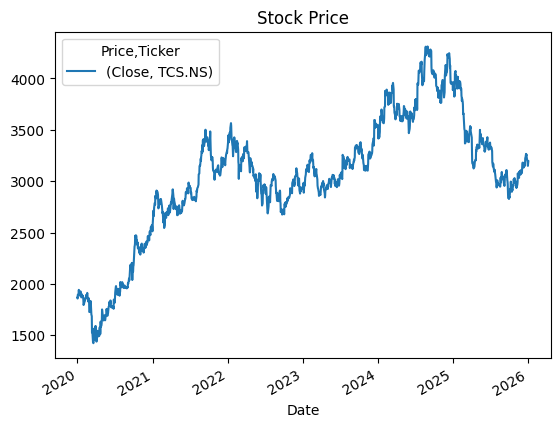

In [ ]:
stock = yf.download("TCS.NS", start="2020-01-01", end="2026-01-04")

data = stock[['Close']]
data.plot(title="Stock Price")
plt.show()

In [ ]:
data_nn = stock[['Close']].copy()
data_nn.dropna(inplace=True)

In [ ]:
data

Price,Close
Ticker,TCS.NS
Date,
2020-01-01,1866.114258
2020-01-02,1857.547729
2020-01-03,1894.566528
2020-01-06,1894.394775
2020-01-07,1899.044189
...,...
2025-12-29,3193.446533
2025-12-30,3188.830566


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_nn)

In [ ]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

import numpy as np
X, y = np.array(X), np.array(y)

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(X.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0623
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0025
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0013
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.8703e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.5683e-04
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 9.2426e-04
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.8450e-04
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.8225e-04
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.5653e-04
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.0908e-04


In [ ]:
pred = model.predict(X)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [ ]:
pred = scaler.inverse_transform(pred)
y_actual = scaler.inverse_transform(y)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_actual, pred))
print("RMSE:", rmse)

RMSE: 80.6512919887467


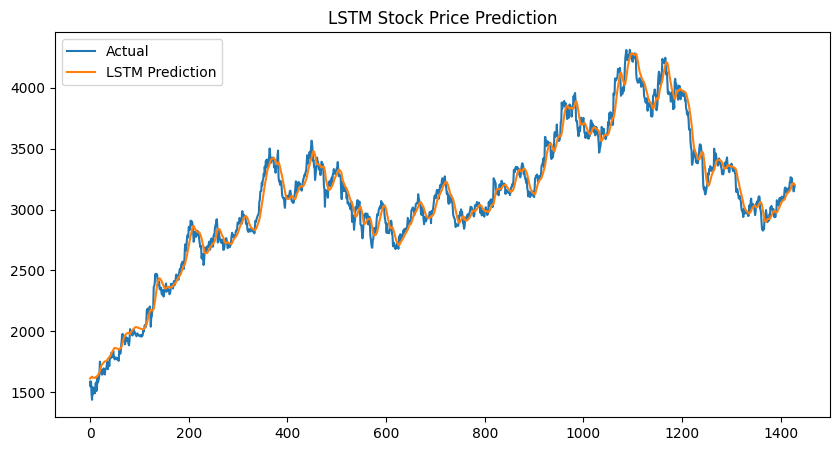

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_actual, label="Actual")
plt.plot(pred, label="LSTM Prediction")

plt.title("LSTM Stock Price Prediction")
plt.legend()
plt.show()

In [ ]:
last_60_days = scaled_data[-60:]

In [ ]:
future_predictions = []

current_input = last_60_days.reshape(1, 60, 1)

for i in range(30):
    next_pred = model.predict(current_input)[0][0]
    future_predictions.append(next_pred)

    # update input
    current_input = np.append(current_input[:,1:,:], [[[next_pred]]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 

In [ ]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [ ]:
import pandas as pd

future_dates = pd.date_range(start=data_nn.index[-1], periods=31, freq='B')[1:]

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': future_predictions.flatten()
})

future_df.set_index('Date', inplace=True)

print(future_df)

            Predicted_Close
Date                       
2026-01-05      3202.468018
2026-01-06      3200.796143
2026-01-07      3199.682129
2026-01-08      3198.927490
2026-01-09      3198.420898
2026-01-12      3198.084473
2026-01-13      3197.865967
2026-01-14      3197.728271
2026-01-15      3197.645508
2026-01-16      3197.599854
2026-01-19      3197.579834
2026-01-20      3197.576660
2026-01-21      3197.583984
2026-01-22      3197.598389
2026-01-23      3197.617676
2026-01-26      3197.639404
2026-01-27      3197.663574
2026-01-28      3197.687988
2026-01-29      3197.712402
2026-01-30      3197.737793
2026-02-02      3197.761963
2026-02-03      3197.787109
2026-02-04      3197.812012
2026-02-05      3197.836670
2026-02-06      3197.861084
2026-02-09      3197.885254
2026-02-10      3197.909668
2026-02-11      3197.933594
2026-02-12      3197.958008
2026-02-13      3197.981689


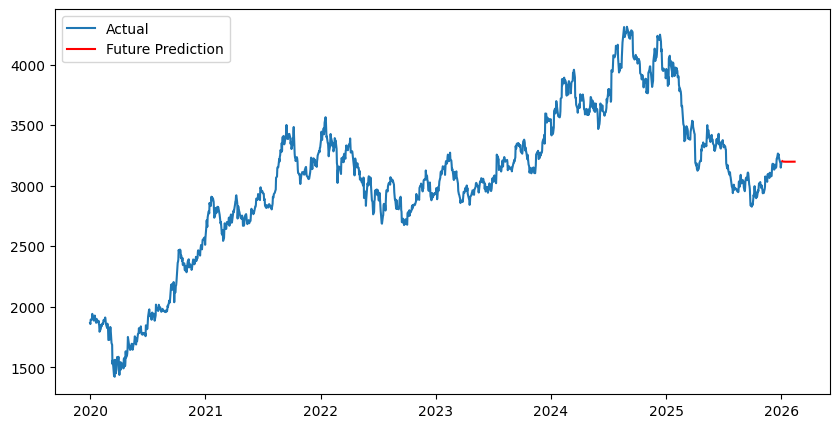

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data_nn['Close'], label="Actual")
plt.plot(future_df['Predicted_Close'], label="Future Prediction", color='red')

plt.legend()
plt.show()